# Notebook 01 — Single-Asset Optimal Quotes (IG & HY)

Reproduces Figures 1–5 (IG) and 10–14 (HY).

Model A (CARA utility)  
ξ = γΔ  
ODE solved via implicit scheme + Newton method.

We plot:
- δ^bid(t, n)
- δ^bid(0, n)
- δ^ask(0, n)
- Spread vs inventory
- Skew vs inventory

## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import sys
sys.path.append(str(Path().resolve().parents[0]))

from asset.params import IG, HY, GAMMA, T
from src.ode_solver_1d import solve_general

plt.style.use("seaborn-v0_8")

## 1) Solve ODE (Model A)

In [3]:
print("Solving IG Model A ...")
sol_ig = solve_general(IG, GAMMA, T, xi=GAMMA, N_t=7200)

print("Solving HY Model A ...")
sol_hy = solve_general(HY, GAMMA, T, xi=GAMMA, N_t=7200)

Solving IG Model A ...
Solving HY Model A ...


## 2) Plot

In [4]:
def plot_asset(sol, params, label):
    lots = sol["lots"]
    times = sol["times"]
    Q = int(params["Q"])

    # ─────────────────────────────────────────────
    # 1) δ^bid(t, n)
    # ─────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = plt.cm.coolwarm(np.linspace(0, 1, 2 * Q - 1))

    for i, n in enumerate(range(-Q + 1, Q)):
        i_lot = int(n + Q)
        db = sol["delta_bid"][:, i_lot]
        if np.all(np.isnan(db)):
            continue
        ax.plot(times, db, color=colors[i], label=f"n={n:+d}", linewidth=1)

    ax.set_xlabel("t (s)")
    ax.set_ylabel("δ^bid")
    ax.set_title(f"{label} — δ^bid(t, n)")
    ax.legend(fontsize=7, ncol=3)
    ax.grid(alpha=0.3)
    plt.show()

    # ─────────────────────────────────────────────
    # 2) δ^bid(0, n)
    # ─────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 5))
    ns = lots[1:]
    db0 = sol["delta_bid"][0, 1:]
    mask = np.isfinite(db0)

    ax.plot(ns[mask], db0[mask], "x-", markersize=8)
    ax.set_xlabel("Inventory n")
    ax.set_ylabel("δ^bid")
    ax.set_title(f"{label} — δ^bid(0, n)")
    ax.grid(alpha=0.3)
    plt.show()

    # ─────────────────────────────────────────────
    # 3) δ^ask(0, n)
    # ─────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 5))
    ns = lots[:-1]
    da0 = sol["delta_ask"][0, :-1]
    mask = np.isfinite(da0)

    ax.plot(ns[mask], da0[mask], "o-", markersize=8)
    ax.set_xlabel("Inventory n")
    ax.set_ylabel("δ^ask")
    ax.set_title(f"{label} — δ^ask(0, n)")
    ax.grid(alpha=0.3)
    plt.show()

    # ─────────────────────────────────────────────
    # 4) Spread
    # ─────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 5))
    spread = sol["delta_bid"][0, :] + sol["delta_ask"][0, :]
    mask = np.isfinite(spread)

    ax.plot(lots[mask], spread[mask], "s-")
    ax.set_xlabel("Inventory n")
    ax.set_ylabel("Spread δ^b + δ^a")
    ax.set_title(f"{label} — Spread vs inventory")
    ax.grid(alpha=0.3)
    plt.show()

    # ─────────────────────────────────────────────
    # 5) Skew
    # ─────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 5))
    skew = sol["delta_bid"][0, :] - sol["delta_ask"][0, :]
    mask = np.isfinite(skew)

    ax.plot(lots[mask], skew[mask], "D-")
    ax.set_xlabel("Inventory n")
    ax.set_ylabel("Skew δ^b − δ^a")
    ax.set_title(f"{label} — Skew vs inventory")
    ax.grid(alpha=0.3)
    plt.show()

=== IG Figures (1–5) ===


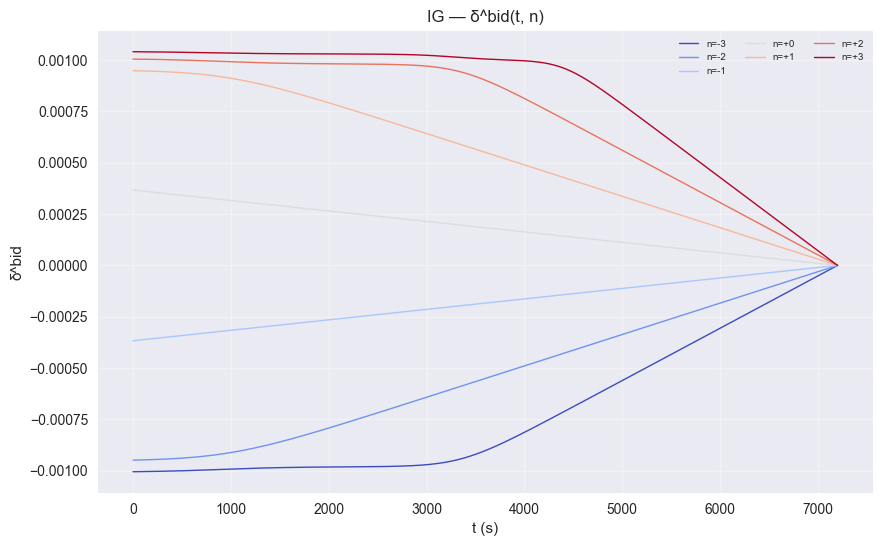

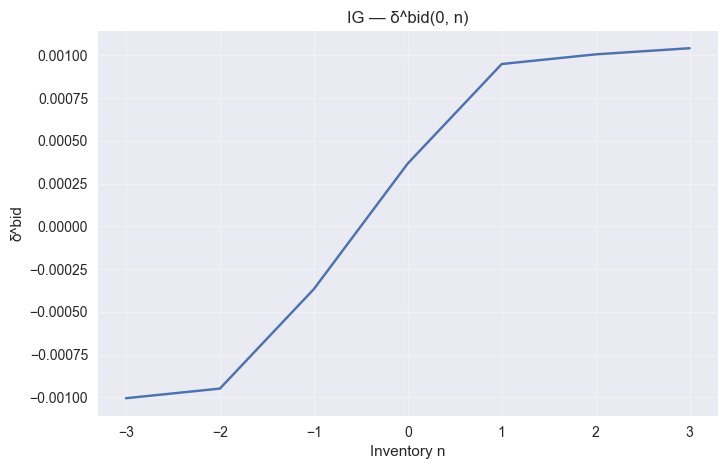

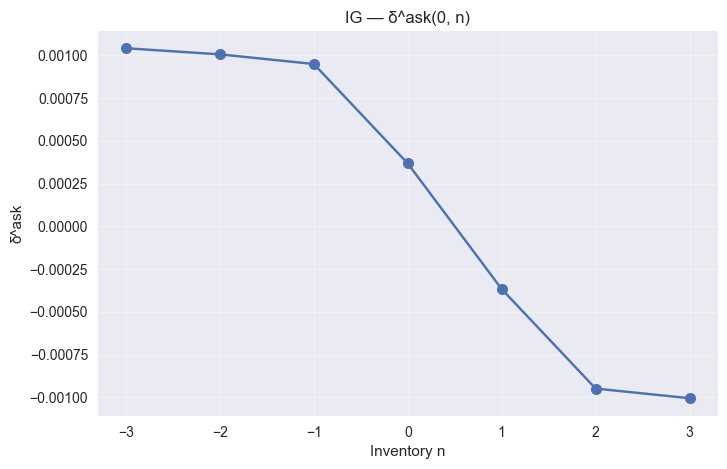

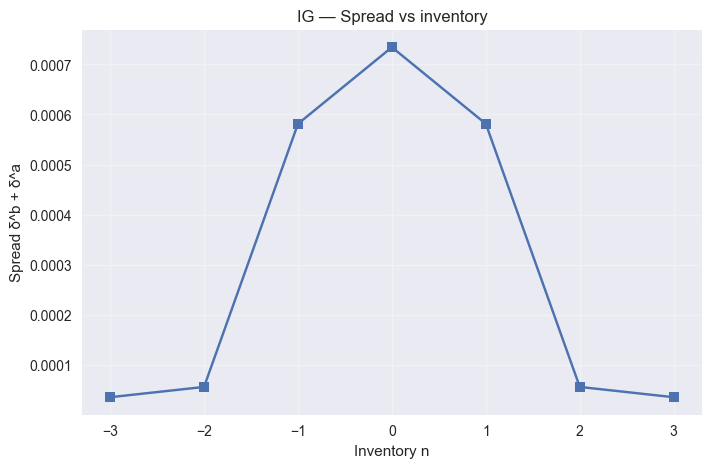

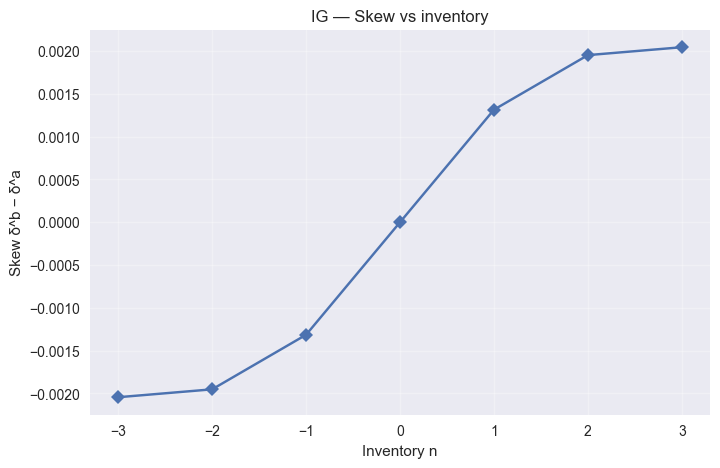

In [5]:
print("=== IG Figures (1–5) ===")
plot_asset(sol_ig, IG, "IG")